# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Covid Data Set.csv")

df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,AF,Afghanistan,EMR,NaN,0,NaN,0
1,2020-01-04,DZ,Algeria,AFR,NaN,0,NaN,0
2,2020-01-04,AL,Albania,EUR,NaN,0,NaN,0
3,2020-01-04,AI,Anguilla,AMR,NaN,0,NaN,0
4,2020-01-04,AS,American Samoa,WPR,0.0,0,0.0,0


Description:

The data set was picked through some reasearching for covid cvs files that had both time, deaths, and locations of cases, and I was able to stumble upon this site that contained the data I was looking for: https://data.humdata.org/dataset/coronavirus-covid-19-cases-and-deaths

represents the deaths caused by COVID-19 in different countries as well as different times, it also provides the amount to of cases, cumalitive cases, and new deaths.

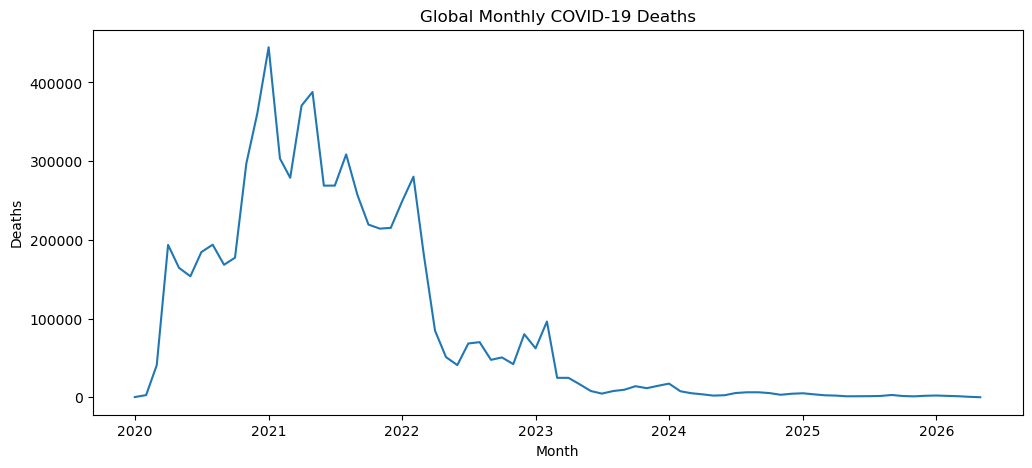

In [9]:
# Create month column
df["Date_reported"] = pd.to_datetime(df["Date_reported"])
df["Month"] = df["Date_reported"].dt.to_period("M")

# Sum of deaths each month
monthly_deaths = df.groupby("Month")["New_deaths"].sum()
monthly_deaths.index = monthly_deaths.index.to_timestamp()

# Plot
plt.figure(figsize=(12,5))

plt.plot(monthly_deaths.index, monthly_deaths.values)

plt.xlabel("Month")
plt.ylabel("Deaths")
plt.title("Global Monthly COVID-19 Deaths")

plt.show()

The data above represents the amount of deaths from 2020 to 2026. When the COVID-19 first started we can see a huge spike in deaths from 0 to 200,000 people at the beggining of the year of 2020, and even more closing in on 2021. From 2021 we see the deaths fluctuate but steadily go lower and lower, and this trend repeats as time passed and vaccines were made, and people started wearing masks to prevent the virus from spreading, we started finding new ways to counteract the virus and so the deaths declined in accordance. As for space this graph does not show space.

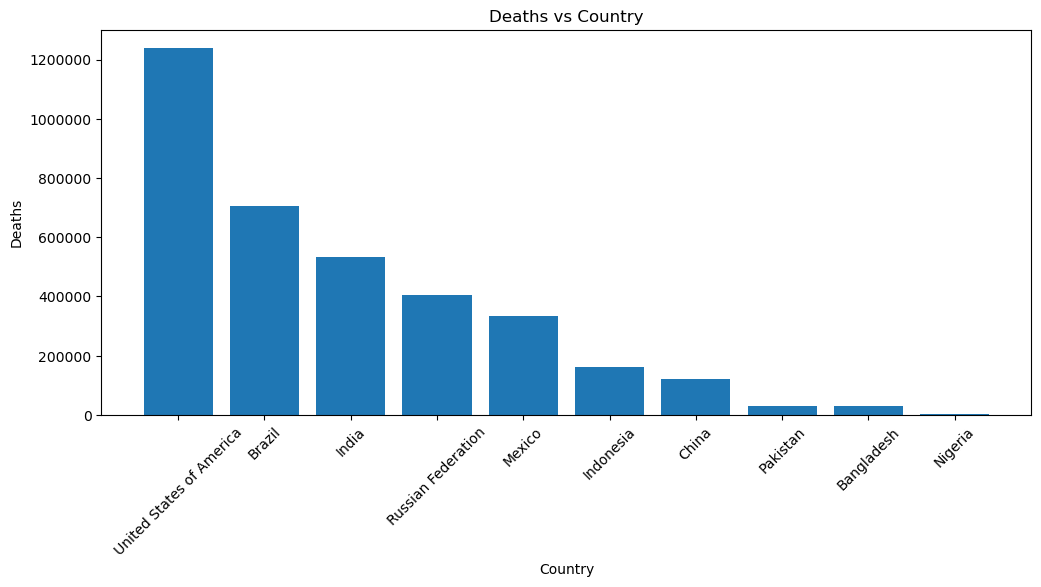

In [18]:
# Main countries
main_countries = [
    "India",
    "China",
    "United States of America",
    "Indonesia",
    "Pakistan",
    "Nigeria",
    "Brazil",
    "Bangladesh",
    "Russian Federation",
    "Mexico"
]

# Organize data and dataset
filtered_df = df[df["Country"].isin(main_countries)]
country_deaths = filtered_df.groupby("Country")["New_deaths"].sum()
country_deaths = country_deaths.sort_values(ascending=False)

# Graphing
fig, ax = plt.subplots(figsize=(12,5))

ax.bar(country_deaths.index, country_deaths.values)


ax.set_xlabel("Country")
ax.set_ylabel("Deaths")
ax.set_title("Deaths vs Country")

plt.xticks(rotation=45)

ax.ticklabel_format(style='plain', axis='y')

plt.show()

The graph above shows how deaths occured throughout space. The countries picked were the countries that popped up when I googled the biggest countries by population, I chose the top 10, and created a graph to represent how many deaths happened in total in each country. The graph shows that the top 3 countries with the highest death were USA, Brazil, and India. USA; however, had almost twice as much as any other country which is interesting to see. For time relationship it is through the span of 2020 to 2026.

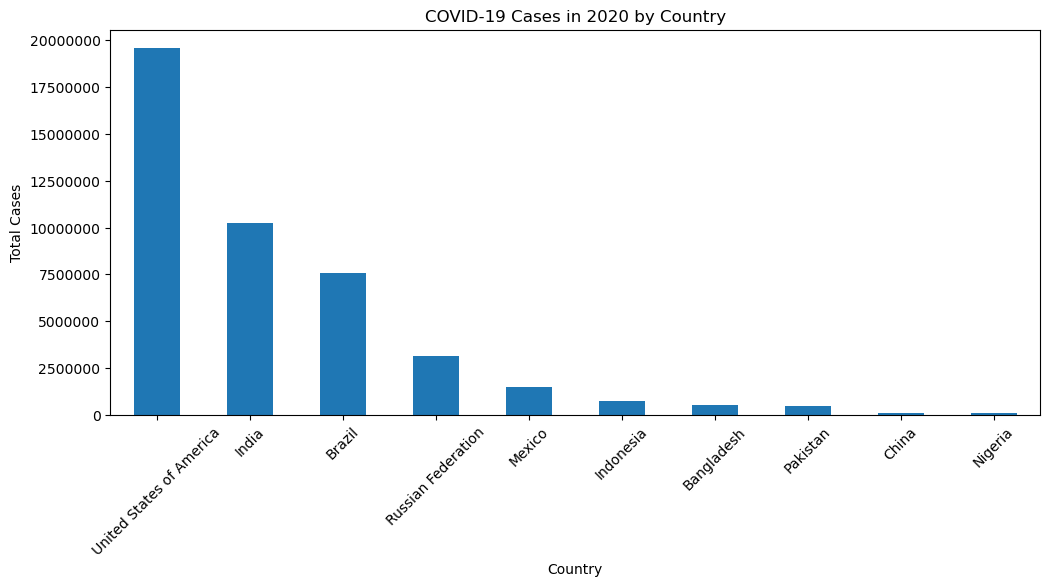

In [24]:
# Convert to datetime
df["Date_reported"] = pd.to_datetime(df["Date_reported"])

# Filter for 2020
df_2020 = df[df["Date_reported"].dt.year == 2020]

# Filter for main countries
filtered_df = df_2020[df_2020["Country"].isin(main_countries)]

# Total cases by country
cases_2020 = (
    filtered_df.groupby("Country")["New_cases"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,5))

ax = cases_2020.plot(kind="bar")

plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.title("COVID-19 Cases in 2020 by Country")

plt.xticks(rotation=45)

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='y')


plt.show()

The above graph showcases the amount of cases through the time of 2020 when the pandemic was most severe, through the main countries. The graph is almost identical to the second graph with the only difference being that india had more cases than brazil at least in 2020 which is quite interesting. Still; however, the USA was unfortunately at the top with over 17 million cases.